In [159]:
from sklearn.datasets import make_classification

In [160]:
import numpy as np

In [161]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, random_state=41, n_classes=2, n_clusters_per_class=1, hypercube=False, class_sep=10)

In [162]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Feature 2')

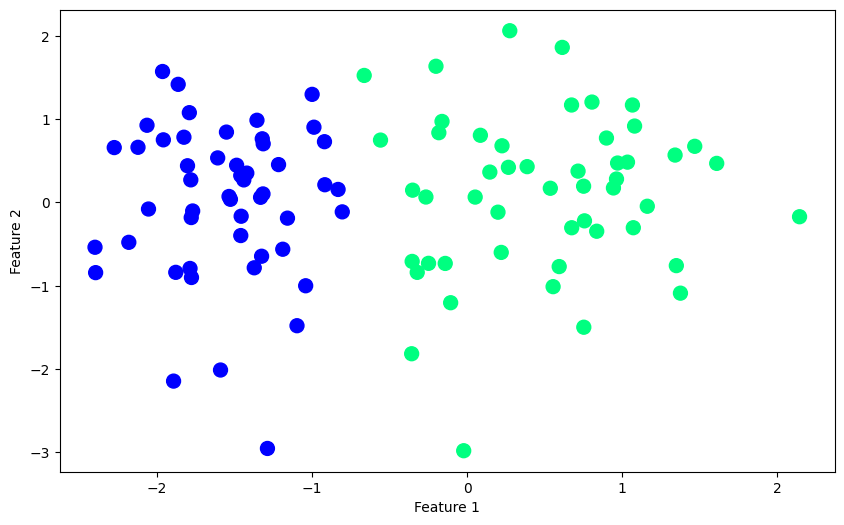

In [163]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

In [164]:
X[:5], y[:5]

(array([[ 0.19924745, -0.11697552],
        [-0.24882029, -0.73115232],
        [-0.3544904 , -0.7081059 ],
        [-1.59086506, -2.01199214],
        [-0.20083951,  1.63493163]]),
 array([1, 1, 1, 0, 1]))

In [165]:
def Perceptron(X,y):
  X = np.insert(X, 0, 1, axis=1)
  weight = np.ones(X.shape[1])
  lr = 0.01
  epoche = 1000

  for i in range(epoche):
    j = np.random.randint(0, X.shape[0])
    y_hat = np.dot(X[j], weight)

    weight = weight + lr*(y[j] - y_hat)*X[j]

    return weight


In [166]:
def step(z):
  return 0 if z<0 else 1

In [167]:
weight = Perceptron(X,y)

In [168]:
m = -(weight[0]/weight[2])
c = -(weight[1]/weight[2])

In [169]:
m,c

(np.float64(-1.0015546359229714), np.float64(-0.9871893680249475))

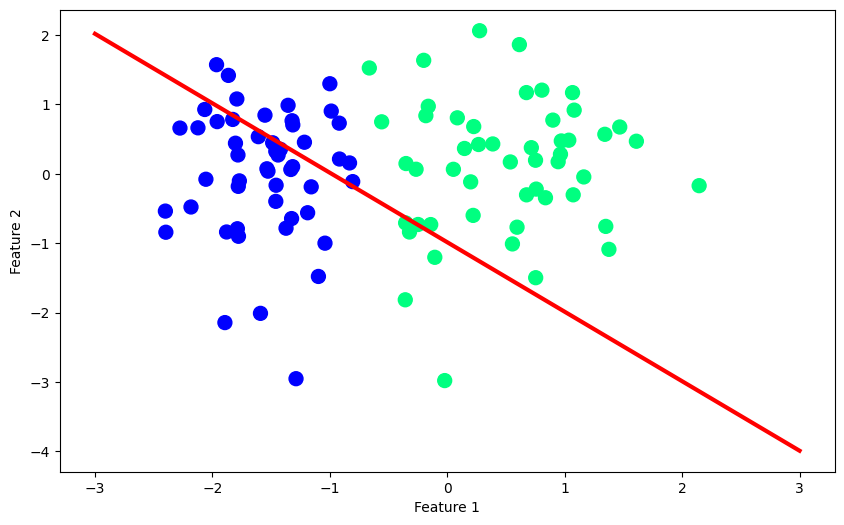

In [170]:
x_input = np.linspace(-3, 3, 100)
y_input = m * x_input + c

plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.plot(x_input, y_input, color='red', linewidth=3)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [173]:
from sklearn.metrics import confusion_matrix
X[:5], weight

(array([[ 0.19924745, -0.11697552],
        [-0.24882029, -0.73115232],
        [-0.3544904 , -0.7081059 ],
        [-1.59086506, -2.01199214],
        [-0.20083951,  1.63493163]]),
 array([1.00461339, 0.99020425, 1.00305401]))

In [175]:
X = np.insert(X, 0, 1, axis=1)
X[:5], weight

(array([[ 1.        ,  0.19924745, -0.11697552],
        [ 1.        , -0.24882029, -0.73115232],
        [ 1.        , -0.3544904 , -0.7081059 ],
        [ 1.        , -1.59086506, -2.01199214],
        [ 1.        , -0.20083951,  1.63493163]]),
 array([1.00461339, 0.99020425, 1.00305401]))

In [179]:
y_hat = np.dot(X, weight)
y_hat.shape, y_hat[:5]

((100,),
 array([ 1.0845763 ,  0.02484522, -0.05667296, -2.58880475,  2.44566599]))

In [180]:
y_pred = np.array([step(i) for i in y_hat])
y_pred[:5]

array([1, 1, 0, 0, 1])

In [181]:
confusion_matrix(y, y_pred)

array([[36, 14],
       [ 5, 45]])

In [182]:
from sklearn.metrics import accuracy_score
accuracy_score(y, y_pred)

0.81